🔍 Iniciando GridSearch para Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
✅ Random Forest finalizado con éxito.
   Mejores parámetros: {'regressor__max_depth': None, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}

🔍 Iniciando GridSearch para XGBoost...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
✅ XGBoost finalizado con éxito.
   Mejores parámetros: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 6, 'regressor__n_estimators': 100}

🔍 Iniciando GridSearch para LGBM Regressor...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/tmp/ipykernel_1006/2278651767.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_metricas.index, y=df_metricas['R2'], ax=ax[0], palette='viridis')
/tmp/ipykernel_1006/2278651767.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_metricas.index, y=df_metricas['RMSE'], ax=ax[1], palette='rocket')


✅ LGBM Regressor finalizado con éxito.
   Mejores parámetros: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 100}


=== RESUMEN DE MÉTRICAS CON MODELOS OPTIMIZADOS (GRIDSEARCH) ===
                     MAE      RMSE        R2
Random Forest   0.031604  0.440238  0.988923
XGBoost         0.041981  0.351132  0.992953
LGBM Regressor  0.086621  0.612121  0.978585


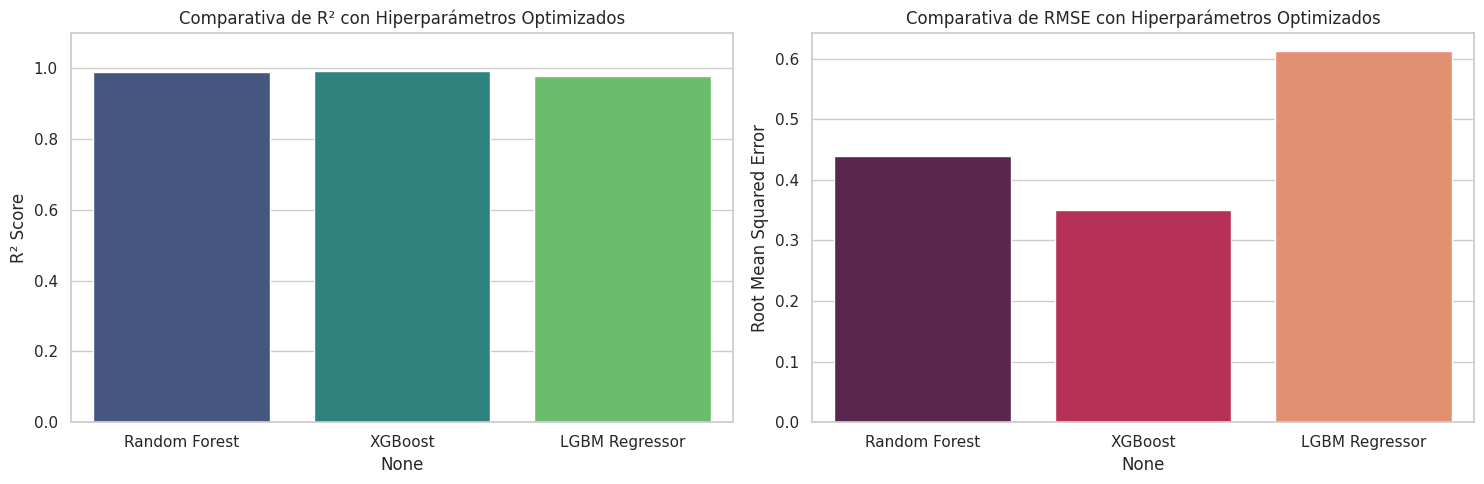

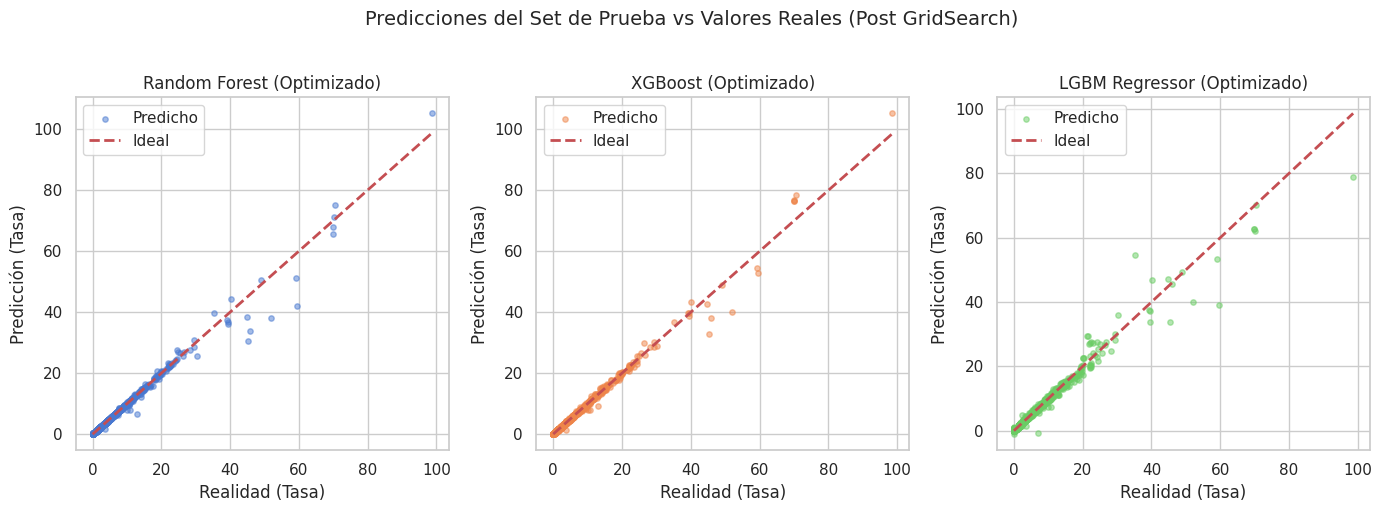

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelos a entrenar
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# 1. Cargar los Datos
#df = pd.read_csv("Dataset_Inicial.xlsx - Sheet1.csv")
df = pd.read_excel('https://github.com/Buster1991/Articulo_Cientifico/raw/refs/heads/main/Dataset_Inicial.xlsx')

# 2. Ingeniería de características para 'Fecha_Completa'
df['Fecha_Completa'] = pd.to_datetime(df['Fecha_Completa'])
df['Fecha_Timestamp'] = df['Fecha_Completa'].astype('int64') // 10**9
df['DPA'] = df['DPA'].astype(str)

# 3. Definir Variables Predictoras (X) y Objetivo (y)
X = df[['DPA', 'Canton', 'Anio', 'Mes', 'Poblacion', 'Homicidios', 'Fecha_Timestamp']]
y = df['Tasa']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Pipeline de Preprocesamiento (Aplica a todos los experimentos)
cat_features = ['DPA', 'Canton']
num_features = ['Anio', 'Mes', 'Poblacion', 'Homicidios', 'Fecha_Timestamp']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

# 5. Definir la Rejilla de Hiperparámetros para cada Modelo
# Nota el prefijo 'regressor__' para que GridSearchCV sepa qué componente del Pipeline tunear
param_grids = {
    'Random Forest': {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [10, 20, None],
        'regressor__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [3, 6, 9],
        'regressor__learning_rate': [0.05, 0.1]
    },
    'LGBM Regressor': {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [5, 10, -1],
        'regressor__learning_rate': [0.05, 0.1]
    }
}

# Definir los estimadores base dentro de estructuras Pipeline vacías
modelos_base = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1),
    'LGBM Regressor': lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1)
}

# 6. Bucle de Optimización, Entrenamiento y Evaluación
resultados = {}
predicciones = {}
mejores_parametros = {}

for nombre in modelos_base.keys():
    print(f"🔍 Iniciando GridSearch para {nombre}...")

    # Crear el pipeline estructural básico
    pipeline_estructural = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', modelos_base[nombre])
    ])

    # Configurar el GridSearchCV sobre el Pipeline completo
    grid_search = GridSearchCV(
        estimator=pipeline_estructural,
        param_grid=param_grids[nombre],
        cv=3,                      # K-Fold Cross Validation de 3 pliegues
        scoring='neg_mean_squared_error', # Métrica de optimización
        n_jobs=-1,                 # Usar todos los procesadores de Colab disponibles
        verbose=1
    )

    # Ejecutar la búsqueda y entrenamiento con el set de datos
    grid_search.fit(X_train, y_train)

    # Guardar los mejores parámetros encontrados
    mejores_parametros[nombre] = grid_search.best_params_

    # Predecir usando el mejor modelo resultante
    mejor_modelo_pipeline = grid_search.best_estimator_
    y_pred = mejor_modelo_pipeline.predict(X_test)
    predicciones[nombre] = y_pred

    # Calcular Métricas Finales de validación
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    resultados[nombre] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"✅ {nombre} finalizado con éxito.")
    print(f"   Mejores parámetros: {grid_search.best_params_}\n")

# Mostrar tabla comparativa final
df_metricas = pd.DataFrame(resultados).T
print("\n=== RESUMEN DE MÉTRICAS CON MODELOS OPTIMIZADOS (GRIDSEARCH) ===")
print(df_metricas.to_string())

# 7. Graficar Comparativa de Métricas Optimizadas
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico R²
sns.barplot(x=df_metricas.index, y=df_metricas['R2'], ax=ax[0], palette='viridis')
ax[0].set_title('Comparativa de R² con Hiperparámetros Optimizados')
ax[0].set_ylabel('R² Score')
ax[0].set_ylim(0, 1.1)

# Gráfico RMSE
sns.barplot(x=df_metricas.index, y=df_metricas['RMSE'], ax=ax[1], palette='rocket')
ax[1].set_title('Comparativa de RMSE con Hiperparámetros Optimizados')
ax[1].set_ylabel('Root Mean Squared Error')

plt.tight_layout()
plt.show()

# 8. Gráfico de Dispersión Cruzada de los Modelos Optimizados
plt.figure(figsize=(14, 5))
for i, (nombre, y_pred) in enumerate(predicciones.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.5, s=15, color=sns.color_palette("muted")[i-1], label='Predicho')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
    plt.title(f'{nombre} (Optimizado)')
    plt.xlabel('Realidad (Tasa)')
    plt.ylabel('Predicción (Tasa)')
    plt.legend()

plt.suptitle('Predicciones del Set de Prueba vs Valores Reales (Post GridSearch)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()